## k-Nearest Neighbors

k-Nearest Neighbors (kNN) is a non-parametric method that makes predictions based on similarity. The idea is: to predict the output for a new data point, look at the k training points most similar to it (its "nearest neighbors"), and either average their outputs (for regression) or take a majority vote (for classification).

### What "similar" means

By default, kNN measures similarity using Euclidean distance — the straight-line distance between two points in the space of predictor values. If you have two predictors X1 and X2, the distance between two observations is computed from both dimensions simultaneously.

This means the **scale of your predictors matters a lot**. If one predictor is measured in thousands and another in single digits, the first one will dominate the distance calculation. For this reason, it's common practice to standardize predictors before using kNN, so each one has a mean of 0 and a standard deviation of 1.

### What k controls

k is the key tuning parameter:

- **Small k** (like k=1): The model only looks at the single nearest neighbor. This means predictions are highly sensitive to individual data points, and the decision boundary becomes very jagged. The model fits the training data extremely well but tends to overfit.
- **Large k** (like k=50): The model averages over many neighbors, which smooths out noise but can also smooth out real patterns. The model is more stable but may underfit.

Choosing k is essentially navigating the bias-variance tradeoff. Smaller k gives lower bias but higher variance; larger k gives higher bias but lower variance. We usually try a range of k values and pick the one that gives the best performance on a validation or test set.

In [1]:
# This shows the output of every line in a cell, not just the last one
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
import pandas as pd
import numpy as np

import sklearn.linear_model as skl_lm
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, ConfusionMatrixDisplay, mean_squared_error, root_mean_squared_error
from sklearn import preprocessing
from sklearn import neighbors

import matplotlib.pyplot as plt

plt.rc('figure', figsize=(25, 9))
np.set_printoptions(precision=4, suppress=True)

## Example: Classifying Iris Flowers

We'll use scikit-learn's built-in Iris dataset — 150 samples of iris flowers, each with four measurements (sepal length, sepal width, petal length, petal width), classified into three species. The goal is to predict species from measurements.

Steps:
1. Load and split the data
2. Standardize the features (important for distance-based models)
3. Fit a kNN classifier
4. Evaluate it
5. Explore how the main hyperparameters affect results

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize: each feature gets mean=0, std=1
scaler = preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train_scaled.shape[0])
print("Test samples:    ", X_test_scaled.shape[0])
print("Features:        ", iris.feature_names)
print("Classes:         ", iris.target_names)

Training samples: 105
Test samples:     45
Features:         ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes:          ['setosa' 'versicolor' 'virginica']


KNeighborsClassifier()

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



Text(0.5, 1.0, 'kNN (k=5) — Confusion Matrix')

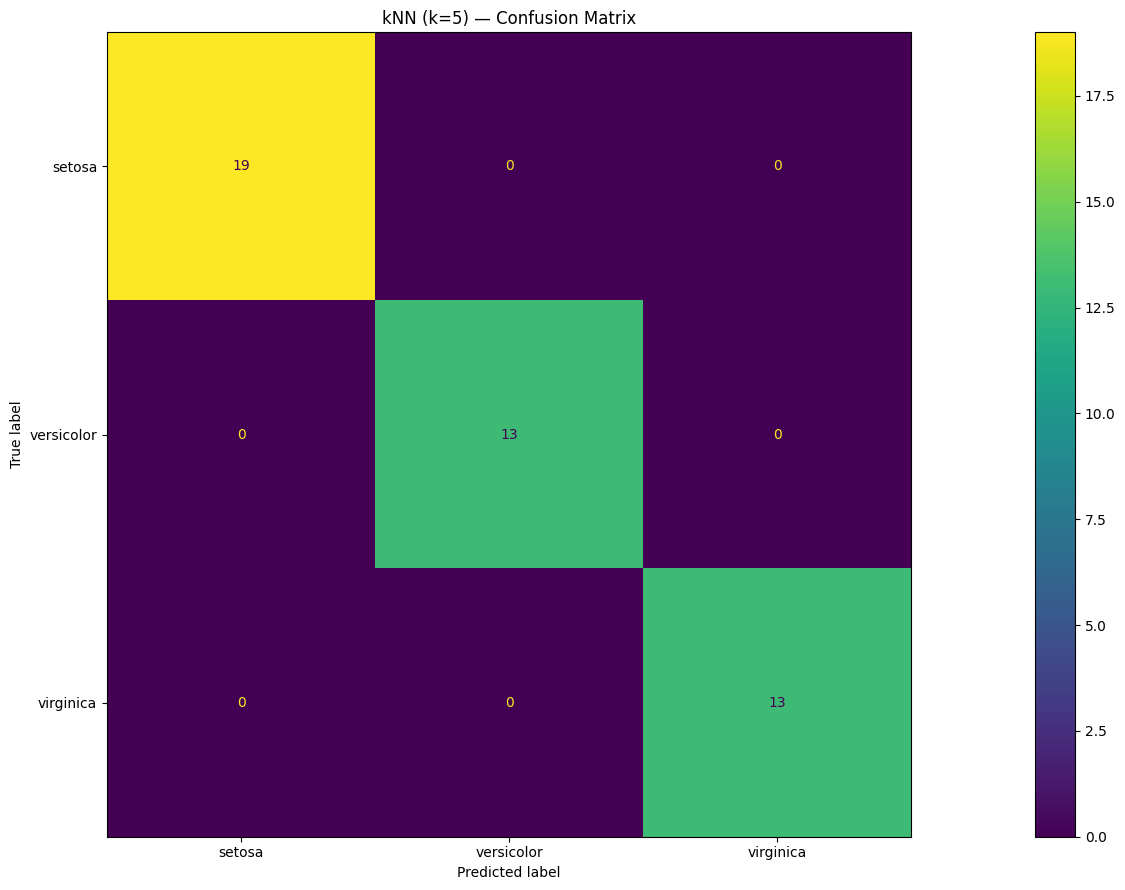

In [4]:
# Fit a basic kNN classifier with k=5
knn = neighbors.KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print(classification_report(y_test, y_pred, target_names=iris.target_names))

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=iris.target_names)
plt.title("kNN (k=5) — Confusion Matrix")
plt.tight_layout()
plt.show()

## Key Hyperparameters

### `n_neighbors` (k)
How many neighbors vote on each prediction. Smaller k = more sensitive to local patterns (lower bias, higher variance). Larger k = smoother but may miss structure (higher bias, lower variance).

### `metric`
The distance function used to find neighbors. Common choices:
- `'euclidean'` (default): straight-line distance — treats all dimensions equally
- `'manhattan'`: sum of absolute differences — moves only along axes, more robust to outliers in individual features
- `'minkowski'` with `p=2`: same as euclidean; with `p=1`: same as manhattan

### `weights`
How much each neighbor contributes to the vote:
- `'uniform'` (default): every neighbor gets one equal vote
- `'distance'`: closer neighbors get more weight — can help when the closest neighbor is clearly more relevant than the 5th-closest

The cell below tries a few combinations so you can see how they compare.

In [5]:
configs = [
    dict(n_neighbors=1,  metric='euclidean', weights='uniform'),
    dict(n_neighbors=5,  metric='euclidean', weights='uniform'),
    dict(n_neighbors=5,  metric='euclidean', weights='distance'),
    dict(n_neighbors=5,  metric='manhattan', weights='uniform'),
    dict(n_neighbors=15, metric='euclidean', weights='uniform'),
]

print(f"{'k':<4} {'metric':<12} {'weights':<10} {'accuracy'}")
print("-" * 42)
for cfg in configs:
    model = neighbors.KNeighborsClassifier(**cfg)
    model.fit(X_train_scaled, y_train)
    acc = model.score(X_test_scaled, y_test)
    print(f"{cfg['n_neighbors']:<4} {cfg['metric']:<12} {cfg['weights']:<10} {acc:.3f}")

k    metric       weights    accuracy
------------------------------------------


KNeighborsClassifier(metric='euclidean', n_neighbors=1)

1    euclidean    uniform    0.978


KNeighborsClassifier(metric='euclidean')

5    euclidean    uniform    1.000


...

5    euclidean    distance   1.000


KNeighborsClassifier(metric='manhattan')

5    manhattan    uniform    1.000


KNeighborsClassifier(metric='euclidean', n_neighbors=15)

15   euclidean    uniform    1.000


## Interactive Decision Boundary

The plot below projects the 4-dimensional Iris data down to 2D using a technique called Principal Component Analysis, or PCA (do not worry about this for right now. It's a thing I'm doing to make it so you can look at 4d data on a 2d plot with your eyeballs). **The kNN model still runs in the original 4D space** — the 2D view is just for visualization.

- **Muted points** = training set, colored by their true class
- **Bright diamond points** = test set, colored by the kNN *prediction*

Use the sliders and dropdowns to change hyperparameters and watch the test-point colors update. When a bright diamond sits in the "wrong" muted cluster, that's a misclassification.

In [6]:
from sklearn.decomposition import PCA
import ipywidgets as widgets
from IPython.display import display

# Project to 2D for visualization only — kNN runs in full 4D space
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train_scaled)
X_test_2d  = pca.transform(X_test_scaled)

TRAIN_COLORS = ['#7bafd4', '#f4a7b9', '#7dbb8a']   # muted blue, pink, green
TEST_COLORS  = ['#0055ff', '#ff00bb', '#00cc44']    # bright blue, magenta, green
NAMES        = iris.target_names

out = widgets.Output()

def update(n_neighbors, metric, weights):
    model = neighbors.KNeighborsClassifier(
        n_neighbors=n_neighbors, metric=metric, weights=weights
    )
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc    = model.score(X_test_scaled, y_test)

    with out:
        out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(9, 6))

        # Training points — muted, circles
        for cls in range(3):
            mask = y_train == cls
            ax.scatter(
                X_train_2d[mask, 0], X_train_2d[mask, 1],
                c=TRAIN_COLORS[cls], s=70, alpha=0.65,
                edgecolors='none', label=f'Train · {NAMES[cls]}'
            )

        # Test points — bright, diamonds, black edge
        for cls in range(3):
            mask = y_pred == cls
            ax.scatter(
                X_test_2d[mask, 0], X_test_2d[mask, 1],
                c=TEST_COLORS[cls], s=110, alpha=1.0, marker='D',
                edgecolors='black', linewidths=0.6,
                label=f'Test pred · {NAMES[cls]}'
            )

        ax.set_xlabel('PCA component 1', fontsize=11)
        ax.set_ylabel('PCA component 2', fontsize=11)
        ax.set_title(
            f'k={n_neighbors}  |  metric={metric}  |  weights={weights}'
            f'  →  test accuracy {acc:.2%}',
            fontsize=12
        )
        ax.legend(loc='upper right', fontsize=9, framealpha=0.8)
        plt.tight_layout()
        plt.show()

# Widgets
k_slider   = widgets.IntSlider(
    value=5, min=1, max=25, step=1,
    description='k (neighbors)',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='380px')
)
metric_dd  = widgets.Dropdown(
    options=['euclidean', 'manhattan', 'chebyshev'],
    value='euclidean', description='metric',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='220px')
)
weights_dd = widgets.Dropdown(
    options=['uniform', 'distance'],
    value='uniform', description='weights',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='200px')
)

controls = widgets.VBox([
    k_slider,
    widgets.HBox([metric_dd, weights_dd])
])

def on_change(_):
    update(k_slider.value, metric_dd.value, weights_dd.value)

k_slider.observe(on_change,   names='value')
metric_dd.observe(on_change,  names='value')
weights_dd.observe(on_change, names='value')

display(widgets.VBox([controls, out]))
update(5, 'euclidean', 'uniform')